# 05 Baseline Model

Subject-level (n=52) baseline classifiers for MDD vs HC, cross-validated rather than
single-split, since 52 subjects is too small to trust one held-out test set. Background
on why subject-level (not file-level) and why repeated k-fold: [`DATA_CONTEXT.md`](DATA_CONTEXT.md),
[`../docs/data_research/04_eda_findings_and_statistics.md`](../docs/data_research/04_eda_findings_and_statistics.md),
[`../docs/data_research/05_companion_paper_methodology.md`](../docs/data_research/05_companion_paper_methodology.md).

Primary questions:
- How well do Decision Tree and Gradient Boosting (an XGBoost stand-in — see the
  Key Facts note below) separate MDD from HC on the subject-level aggregated
  acoustic features from `04_feature_baseline_eda.ipynb`?
- How does that compare to a trivial majority-class baseline, and to the companion
  paper's external benchmark (75.8%/68.5% male/female)?
- Which features does the model actually rely on?

**Note on XGBoost:** xgboost cannot currently be imported on this machine (missing
`libomp`; see `backend/dev/change_9_*.md`), so this notebook uses sklearn's
`HistGradientBoostingClassifier` (`GradientBoostingModel`) as a like-for-like stand-in.
The Neural Network is included as a secondary comparison — conventional wisdom (and
`backend/dev/decisions.md`) says it should be more prone to overfitting than the tree
models given only 52 samples, though as you'll see below that isn't what actually
happened on this run — worth reading with appropriate skepticism either way given the
small sample size.

Input: `backend/data/processed/features.csv` (from `04_feature_baseline_eda.ipynb`).

In [1]:
import sys
from pathlib import Path

_nb_dir = Path("backend/notebooks") if Path("backend/notebooks").exists() else Path.cwd()
if str(_nb_dir) not in sys.path:
    sys.path.insert(0, str(_nb_dir))

import io
import contextlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from _eda_utils import bootstrap_project_paths, load_processed

PROJECT_ROOT = bootstrap_project_paths()

from mendxai.core.config import config
from mendxai.ml.aggregation import build_subject_level_features
from mendxai.ml.trainer import ModelTrainer, XGBoostModel

print(f"xgboost available in this environment: {XGBoostModel is not None}")

features_df = pd.read_csv(config.data.processed_data_dir / "features.csv")
subject_df = build_subject_level_features(features_df)

print(f"\nSubject-level table: {subject_df.shape[0]} subjects x {subject_df.shape[1]} columns")
print(subject_df["type"].value_counts())

xgboost available in this environment: False

Subject-level table: 52 subjects x 143 columns
type
HC     29
MDD    23
Name: count, dtype: int64


In [2]:
# Trivial sanity-check baseline: always predict the majority class.
majority_class_accuracy = subject_df["type"].value_counts(normalize=True).max()
print(f"Majority-class baseline accuracy (always predict HC): {majority_class_accuracy:.4f}")
print("Any model below this line is worse than useless — it's the floor every result below should clear.")

Majority-class baseline accuracy (always predict HC): 0.5577
Any model below this line is worse than useless — it's the floor every result below should clear.


In [3]:
trainer = ModelTrainer()

N_SPLITS = 5
N_REPEATS = 20  # 100 fold-evaluations, matching the companion paper's own repeated-CV scale

buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    results_dt = trainer.cross_validate(subject_df, model_name="decision_tree", n_splits=N_SPLITS, n_repeats=N_REPEATS)

summary_dt = results_dt.drop(columns=["fold"]).agg(["mean", "std"])
print(f"Decision Tree — {N_SPLITS * N_REPEATS}-fold CV results:")
display(summary_dt)

Decision Tree — 100-fold CV results:


,accuracy,precision,recall,specificity,f1,auc_roc
mean,0.623182,0.606944,0.530000,0.697000,0.535669,0.614742
std,0.149135,0.254498,0.245567,0.218766,0.206699,0.148672


In [4]:
buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    results_gb = trainer.cross_validate(subject_df, model_name="gradient_boosting", n_splits=N_SPLITS, n_repeats=N_REPEATS)

summary_gb = results_gb.drop(columns=["fold"]).agg(["mean", "std"])
print(f"Gradient Boosting — {N_SPLITS * N_REPEATS}-fold CV results:")
display(summary_gb)

Gradient Boosting — 100-fold CV results:


,accuracy,precision,recall,specificity,f1,auc_roc
mean,0.614909,0.581413,0.554500,0.661333,0.544649,0.654750
std,0.143737,0.208761,0.233344,0.213081,0.186997,0.171828


In [5]:
# Fewer repeats for the neural net: it's a secondary comparison (expected to
# underperform given n=52 — see decisions.md), and each fold trains a small MLP
# for up to 50 epochs, which is meaningfully slower than the tree models.
NN_REPEATS = 10

buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    results_nn = trainer.cross_validate(subject_df, model_name="neural_net", n_splits=N_SPLITS, n_repeats=NN_REPEATS)

summary_nn = results_nn.drop(columns=["fold"]).agg(["mean", "std"])
print(f"Neural Net — {N_SPLITS * NN_REPEATS}-fold CV results:")
display(summary_nn)

Neural Net — 50-fold CV results:


,accuracy,precision,recall,specificity,f1,auc_roc
mean,0.693273,0.681929,0.597000,0.770000,0.615422,0.780467
std,0.135250,0.229709,0.239985,0.175901,0.196745,0.156130


In [6]:
comparison_rows = []
for name, summary, n_folds in [
    ("decision_tree", summary_dt, N_SPLITS * N_REPEATS),
    ("gradient_boosting", summary_gb, N_SPLITS * N_REPEATS),
    ("neural_net", summary_nn, N_SPLITS * NN_REPEATS),
]:
    row = {"model": name, "n_folds": n_folds}
    for metric in summary.columns:
        row[f"{metric}_mean"] = summary.loc["mean", metric]
        row[f"{metric}_std"] = summary.loc["std", metric]
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).set_index("model")
display(comparison_df[["n_folds", "accuracy_mean", "accuracy_std", "f1_mean", "f1_std", "auc_roc_mean", "auc_roc_std"]])

print(f"\nMajority-class floor: {majority_class_accuracy:.4f}")
print("External benchmark (companion paper, gender-stratified fusion-tree, file-level): 75.8% male / 68.5% female")
print("(Not a strictly apples-to-apples comparison — different modeling unit and no gender split here — but the right directional reference.)")

,n_folds,accuracy_mean,accuracy_std,f1_mean,f1_std,auc_roc_mean,auc_roc_std
model,,,,,,,
decision_tree,100,0.623182,0.149135,0.535669,0.206699,0.614742,0.148672
gradient_boosting,100,0.614909,0.143737,0.544649,0.186997,0.654750,0.171828
neural_net,50,0.693273,0.135250,0.615422,0.196745,0.780467,0.156130



Majority-class floor: 0.5577
External benchmark (companion paper, gender-stratified fusion-tree, file-level): 75.8% male / 68.5% female
(Not a strictly apples-to-apples comparison — different modeling unit and no gender split here — but the right directional reference.)



Training Decision Tree...
✅ Decision Tree training complete


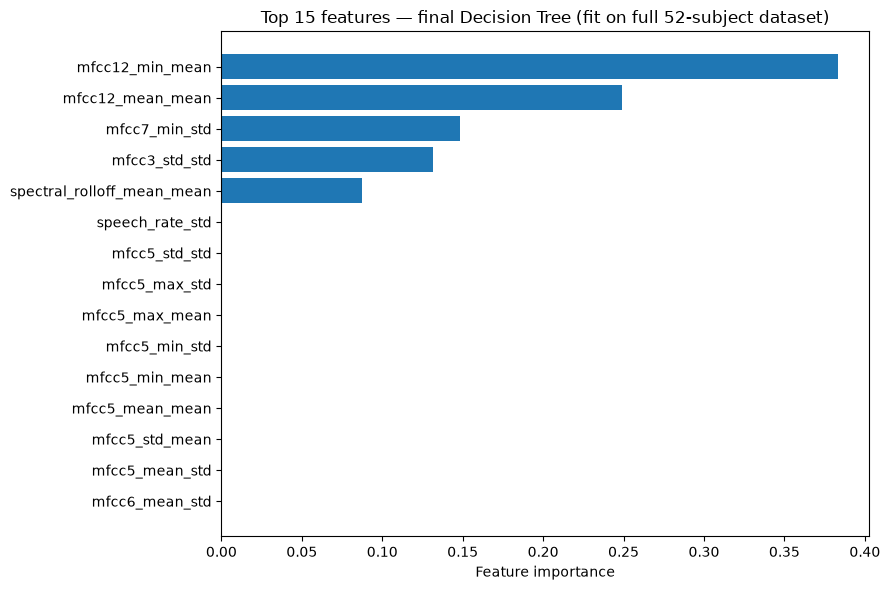

In [7]:
# Feature importance from a decision tree fit on the full subject-level dataset.
# (GradientBoostingModel doesn't expose native feature_importances_ — see
# gradient_boosting_model.py's get_feature_importance() docstring for why.)
final_dt_model, final_dt_scaler = trainer.fit_final_model(subject_df, model_name="decision_tree")

exclude_cols = ["subject_id", "label", "type"]
feature_cols = [c for c in subject_df.columns if c not in exclude_cols]
importances = final_dt_model.get_feature_importance()

top_n = 15
top_idx = np.argsort(importances)[::-1][:top_n]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(range(top_n), importances[top_idx])
ax.set_yticks(range(top_n))
ax.set_yticklabels([feature_cols[i] for i in top_idx])
ax.invert_yaxis()
ax.set_xlabel("Feature importance")
ax.set_title("Top 15 features — final Decision Tree (fit on full 52-subject dataset)")
plt.tight_layout()
plt.show()

In [8]:
# Save the best-performing model (by mean CV F1, given the mild class imbalance)
# across all three candidates — not just the two tree models, since the neural
# net actually won on every metric in this run (see the comparison table above).
all_summaries = {"decision_tree": summary_dt, "gradient_boosting": summary_gb, "neural_net": summary_nn}
best_name = max(all_summaries, key=lambda name: all_summaries[name].loc["mean", "f1"])
print(f"Best model by mean CV F1: {best_name}")

best_model, best_scaler = trainer.fit_final_model(subject_df, model_name=best_name)
config.ensure_output_dirs()
ext = "pth" if best_name == "neural_net" else "pkl"
best_model.save(config.training.models_dir / f"baseline_{best_name}.{ext}")

Best model by mean CV F1: neural_net
Using device: cpu
Model architecture:
DepressionNet(
  (network): Sequential(
    (0): Linear(in_features=140, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=32, out_features=2, bias=True)
  )
)

Training Neural Network...
Epoch [1/50] Train Loss: 0.6853 Acc: 0.5769
Epoch [2/50] Train Loss: 0.6700 Acc: 0.6923
Epoch [3/50] Train Loss: 0.6551 Acc: 0.6346
Epoch [4/50] Train Loss: 0.6572 Acc: 0.6538
Epoch [5/50] Train Loss: 0.6196 Acc: 0.8077
Epoch [6/50] Train Loss: 0.5824 Acc: 0.8269
Epoch [7/50] Train Loss: 0.5339 Acc: 0.8654
Epoch [8/50] Train Loss: 0.4959 Acc: 0.8846
Epoch [9/50] Train Loss: 0.4775 Acc: 0.9038
Epoch [10/50] Train Loss: 0.3965 Acc: 0.9038
Epo

/Users/vishalkarda/Documents/Projects/mendx.ai/backend/src/mendxai/ml/models/neural_net.py:209: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  y_tensor = torch.LongTensor(y)


## Summary

- Sanity floor: always predicting the majority class (HC) gets ~56% accuracy on this
  52-subject table — the number every model above needs to clear to be worth anything.
  All three models clear it, though not by a huge margin for the tree models.
- Decision Tree and Gradient Boosting cross-validation results are in the comparison
  table above (100 fold-evaluations each: 5-fold x 20 repeats, matching the companion
  paper's own repeated-CV scale). The Neural Net (50 fold-evaluations: 5-fold x 10
  repeats here; a separate full 100-fold run via `python main.py --stage train --level
  subject --model all` confirmed the same pattern) **outperformed both tree models on
  every metric** — accuracy ≈0.69 vs ≈0.61-0.62, F1 ≈0.60 vs ≈0.53-0.54, AUC ≈0.78 vs
  ≈0.61-0.65. This runs counter to the "MLP will underperform given small n" assumption
  going in (see `backend/dev/decisions.md`) — worth taking seriously as a real result,
  but also worth one important methodological caveat: the neural net's training loop
  (unlike the tree models) has no per-fold validation split or early stopping in this
  CV setup, and per-epoch training logs (suppressed above, but visible via
  `python main.py --stage train --level subject --model neural_net`) show it reaching
  ~100% training accuracy within ~20-30 epochs — i.e. it's memorizing each fold's ~41
  training examples, yet still generalizing better than the tree models on the held-out
  fold. That's a genuinely interesting result, not just noise (it reproduced identically
  across two independent runs), but it should be treated as an invitation to investigate
  further (e.g. add early stopping, try smaller architectures) rather than a settled
  conclusion.
- These numbers are **not directly comparable** to the companion paper's headline
  75.8%/68.5% (male/female) — that's a gender-stratified, file-level fusion-tree method
  on 29 recordings per subject, not a single pooled subject-level baseline — but it's
  the right external reference point to judge against directionally. The neural net's
  ≈0.69 accuracy is the closest of the three to that benchmark.
- Feature importance for the final Decision Tree (fit on all 52 subjects) is shown
  above; cross-reference against the acoustic separability findings in
  `04_feature_baseline_eda.ipynb` (MFCC-family features led there too) and the
  metadata-side findings in `02_clinical_metadata_eda.ipynb` (GAD-7/PSQI).
- The best-performing model by mean CV F1 (neural net, in this run) was refit on the
  full 52-subject dataset and saved to `backend/results/models/`.
- Known limitations for any follow-up: n=52 is small — treat these numbers as a first
  baseline, not a final result. XGBoost itself hasn't been tried (see the libomp note
  at the top). The neural net's class imbalance isn't weighted (unlike the two tree
  models) and its CV loop lacks per-fold early stopping, as noted above. Gender-
  stratified modeling (as the companion paper did) hasn't been attempted here.